In [44]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import ast
import json
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "figure.titlesize": 18,
})

ALGO_COLORS = {
    "nads_binary_search": "#d62728",  # most important
    "approx": "#1f77b4",              # most important
    "goldberg_liu": "#2ca02c",        # most important
    "degree_threshold": "#9467bd",
    "degree_discount": "#ff7f0e",
    "degree_connected": "#8c564b",
    "degree": "#e377c2",
    "betweenness": "#17becf",
    "high_thetas": "#7f7f7f",
}

save = 0

project_root = Path.cwd()
if not (project_root / "experiments").exists() and (project_root.parent / "experiments").exists():
    project_root = project_root.parent
figures_dir = project_root / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

In [45]:
project_root = Path.cwd()
if not (project_root / "results").exists() and (project_root.parent / "results").exists():
    project_root = project_root.parent

results_dir = project_root / "results" / "technology diffusion"
if not results_dir.exists():
    raise FileNotFoundError(f"Results directory not found: {results_dir}")

temp_results_dir = project_root / "results" / "temp"

def normalize_result_frame(frame, source_file):
    frame = frame.copy()
    frame["source_file"] = source_file.name

    if "history" not in frame.columns:
        frame["history"] = None
    if "selected_seed_nodes" not in frame.columns:
        frame["selected_seed_nodes"] = None

    def parse_selected_seed_nodes(raw):
        if raw is None or (isinstance(raw, float) and pd.isna(raw)):
            return None
        if isinstance(raw, str):
            raw = raw.strip()
            if not raw:
                return None
            try:
                return json.loads(raw)
            except json.JSONDecodeError:
                return ast.literal_eval(raw)
        if isinstance(raw, (list, tuple)):
            return list(raw)
        return raw

    frame["selected_seed_nodes"] = frame["selected_seed_nodes"].apply(parse_selected_seed_nodes)
    return frame

result_csv_files = sorted(results_dir.glob("technology_diffusion_results__*.csv"))
if not result_csv_files:
    fallback = results_dir / "technology_diffusion_results.csv"
    if fallback.exists():
        result_csv_files = [fallback]

frames = [normalize_result_frame(pd.read_csv(file), file) for file in result_csv_files]

if not frames:
    raise FileNotFoundError("No technology_diffusion_results CSV files were found.")

df_results = pd.concat(frames, ignore_index=True)

for col in ["n_nodes", "c", "seed", "total_time", "K"]:
    if col in df_results.columns:
        df_results[col] = pd.to_numeric(df_results[col], errors="coerce")

# Worst-case fallback: if K is missing, set K=n_nodes and inject history=[[n_nodes, 0.0]].
if "K" in df_results.columns and "n_nodes" in df_results.columns:
    missing_k_mask = df_results["K"].isna() & df_results["n_nodes"].notna()
    df_results.loc[missing_k_mask, "K"] = df_results.loc[missing_k_mask, "n_nodes"].astype(float)
    if "history" in df_results.columns:
        df_results.loc[missing_k_mask, "history"] = df_results.loc[missing_k_mask, "n_nodes"].apply(
            lambda n: json.dumps([[float(n), 0.0]])
        )

if "algorithm" in df_results.columns and "history" in df_results.columns and "n_nodes" in df_results.columns:
    history_str = df_results["history"].astype("string")
    approx_mask = df_results["algorithm"].eq("approx") & df_results["n_nodes"].notna()

    approx_missing_history = approx_mask & (
        df_results["history"].isna() | history_str.str.strip().isin(["", "[]"])
    )
    df_results.loc[approx_missing_history, "history"] = df_results.loc[approx_missing_history, "n_nodes"].apply(
        lambda n: json.dumps([[float(n), 0.0]])
    )

    def ensure_approx_start_event(raw, n):
        n = float(n)
        if raw is None or (isinstance(raw, float) and pd.isna(raw)):
            return json.dumps([[n, 0.0]])

        parsed = raw
        if isinstance(raw, str):
            raw = raw.strip()
            if not raw:
                return json.dumps([[n, 0.0]])
            try:
                parsed = json.loads(raw)
            except json.JSONDecodeError:
                parsed = ast.literal_eval(raw)

        if not isinstance(parsed, (list, tuple)) or len(parsed) == 0:
            return json.dumps([[n, 0.0]])

        clean = []
        for point in parsed:
            if not isinstance(point, (list, tuple)) or len(point) < 2:
                continue
            try:
                k = float(point[0])
                t = float(point[1])
            except (TypeError, ValueError):
                continue
            if np.isfinite(k) and np.isfinite(t):
                clean.append([k, t])

        if not clean:
            return json.dumps([[n, 0.0]])

        clean.sort(key=lambda p: p[1])
        has_start = any(np.isclose(t, 0.0, atol=1e-12) and np.isclose(k, n, atol=1e-9) for k, t in clean)
        if not has_start:
            clean = [[n, 0.0]] + clean

        return json.dumps(clean)

    df_results.loc[approx_mask, "history"] = df_results.loc[approx_mask].apply(
        lambda row: ensure_approx_start_event(row.get("history"), row.get("n_nodes")),
        axis=1,
    )

print(
    f"Loaded {len(result_csv_files)} result files and {len(df_results)} total rows from {results_dir}."
)
df_results.head()

Loaded 25 result files and 4500 total rows from /Users/matteobergamaschi/Desktop/td_git/results/technology diffusion.


,algorithm,n_nodes,c,seed,total_time,K,history,source_file,selected_seed_nodes
0,approx,200,1,1,2.1976,18.0,"[[200.0, 0.0], [18.0, 2.1976]]",technology_diffusion_results__seed-1.csv,None
1,betweenness,200,1,1,0.2837,39.0,"[[200, 0.0], [100, 0.0741], [50, 0.129], [39, ...",technology_diffusion_results__seed-1.csv,None
2,degree,200,1,1,0.0631,52.0,"[[200, 0.0], [100, 0.0321], [52, 0.0475], [52,...",technology_diffusion_results__seed-1.csv,None
3,degree_connected,200,1,1,0.0214,52.0,"[[200, 0.0], [100, 0.0089], [52, 0.0151], [52,...",technology_diffusion_results__seed-1.csv,None
4,degree_discount,200,1,1,0.1136,55.0,"[[200, 0.0], [100, 0.0423], [56, 0.0653], [55,...",technology_diffusion_results__seed-1.csv,None


In [46]:
algorithm_order = [
    "degree_threshold",
    "degree_discount",
    "degree_connected",
    "degree",
    "betweenness",
    "approx",
    "goldberg_liu",
    "nads_binary_search",
]

plot_df = (
    df_results.groupby(["n_nodes", "algorithm"], as_index=False)
    .agg(mean_K=("K", "mean"), mean_total_time=("total_time", "mean"))
    .sort_values(["n_nodes", "algorithm"])
)

pivot_k = plot_df.pivot(index="n_nodes", columns="algorithm", values="mean_K").sort_index()
available_algorithms = [a for a in algorithm_order if a in pivot_k.columns]

if not available_algorithms:
    raise ValueError("No expected algorithms found in df_results.")

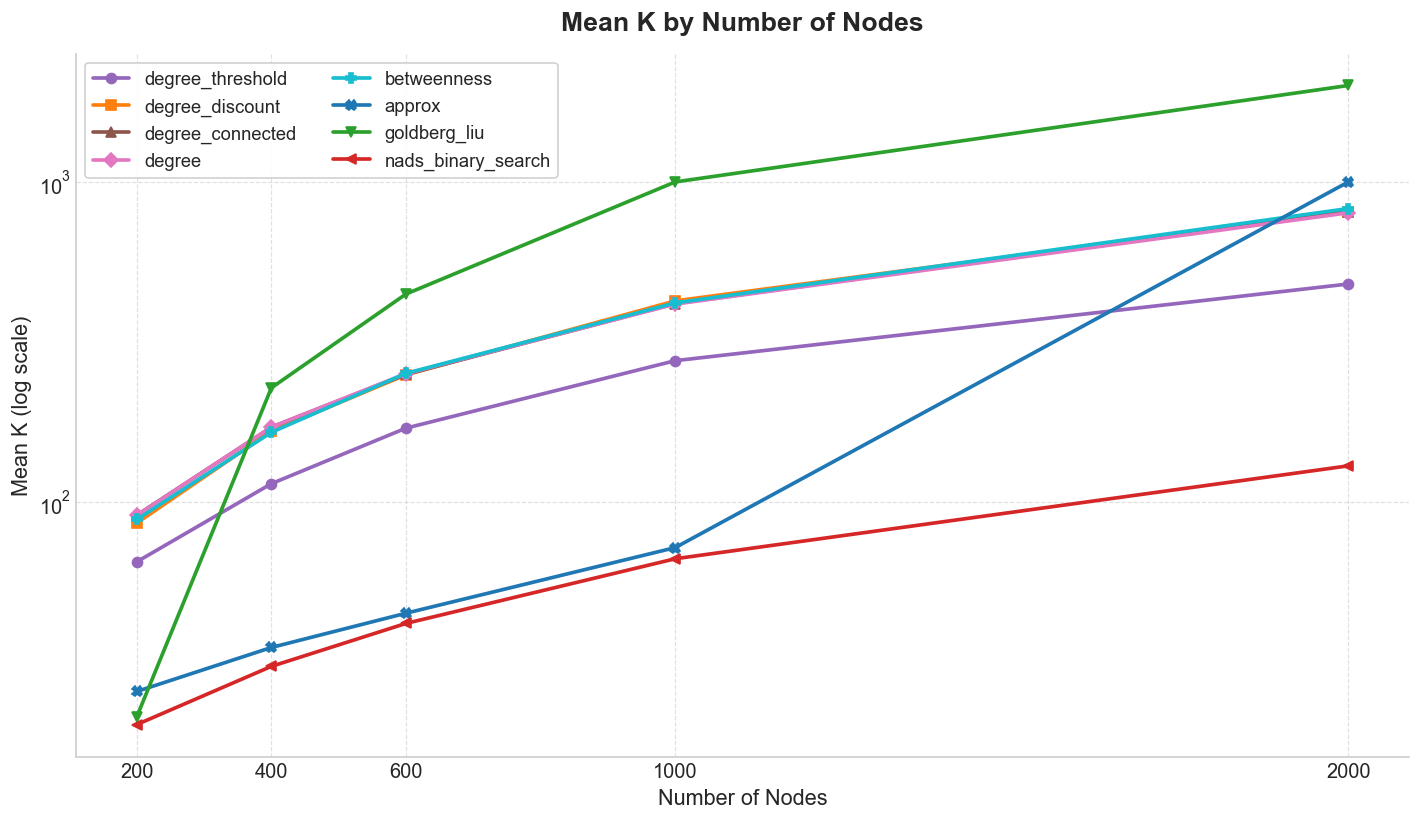

In [47]:
fig, ax = plt.subplots(figsize=(12, 7), dpi=120)

markers = ["o", "s", "^", "D", "P", "X", "v", "<"]
fallback_gl = pd.Series(pivot_k.index, index=pivot_k.index, dtype=float)

for i, alg in enumerate(available_algorithms):
    series = pivot_k[alg]
    if alg == "goldberg_liu":
        series = series.fillna(fallback_gl)

    ax.plot(
        pivot_k.index,
        series,
        marker=markers[i % len(markers)],
        linewidth=2.2,
        color=ALGO_COLORS.get(alg, "#4c4c4c"),
        label=alg,
    )

ax.set_title("Mean K by Number of Nodes", pad=14, weight="bold")
ax.set_xlabel("Number of Nodes")
ax.set_ylabel("Mean K (log scale)")
ax.set_yscale("log")
ax.set_xticks(pivot_k.index.to_list())
ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=True, framealpha=0.9, ncols=2, loc="best")

fig.tight_layout()
if save:
    fig.savefig(figures_dir / "mean_k_by_nodes.png", dpi=220, bbox_inches="tight")
plt.show()

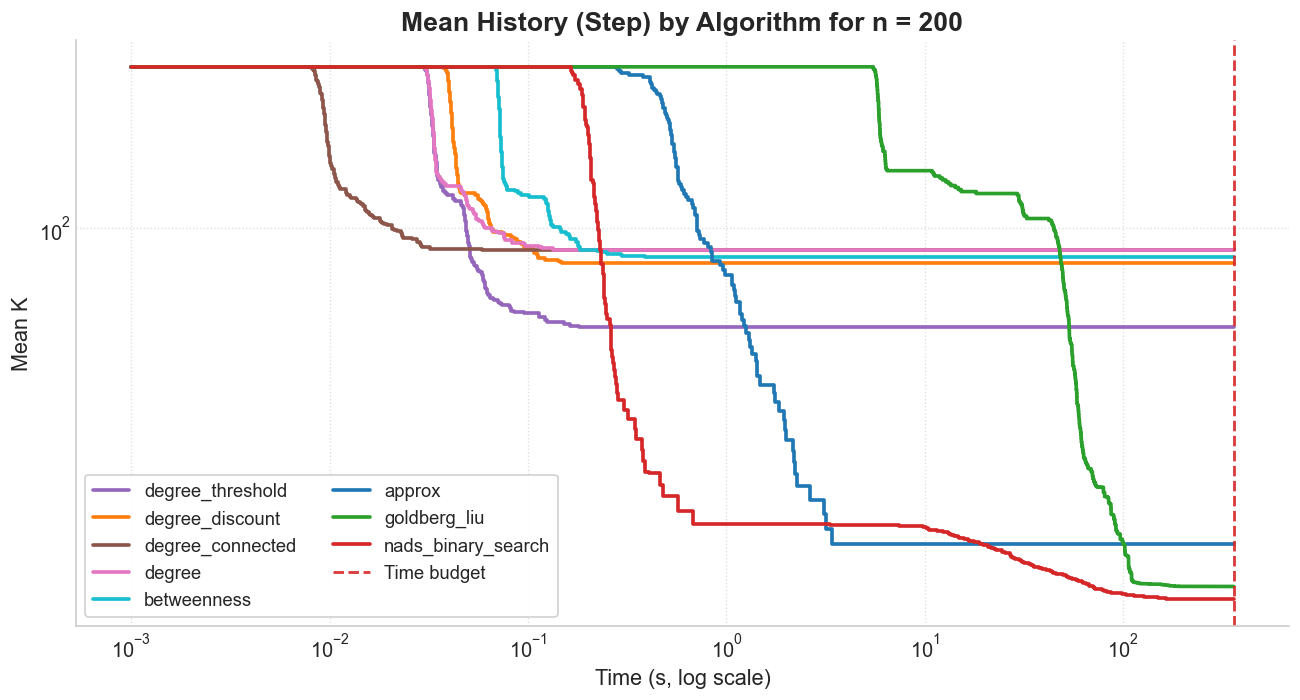

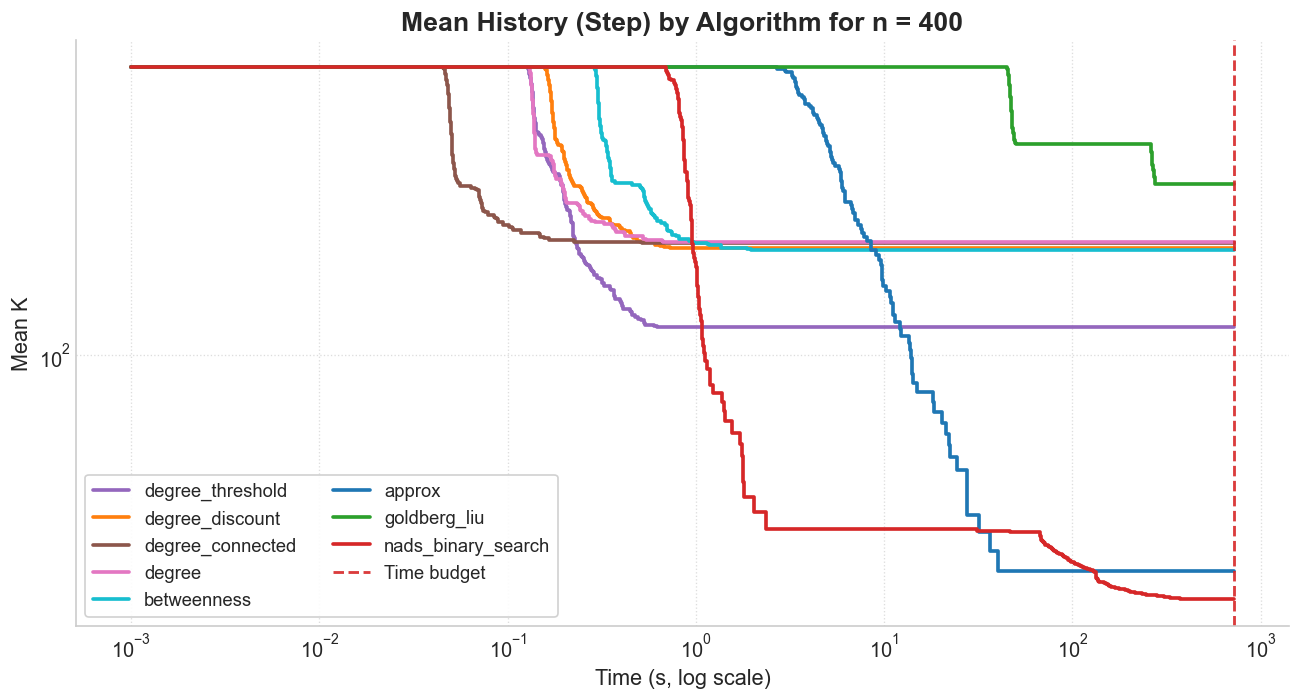

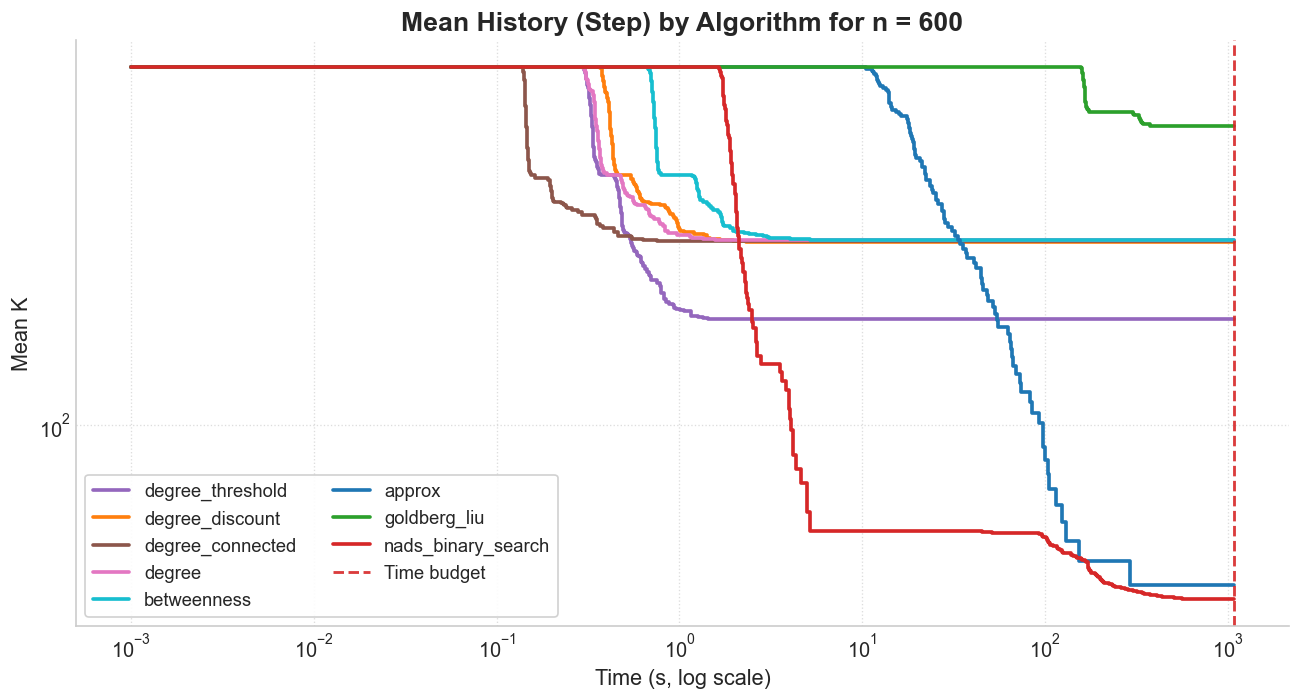

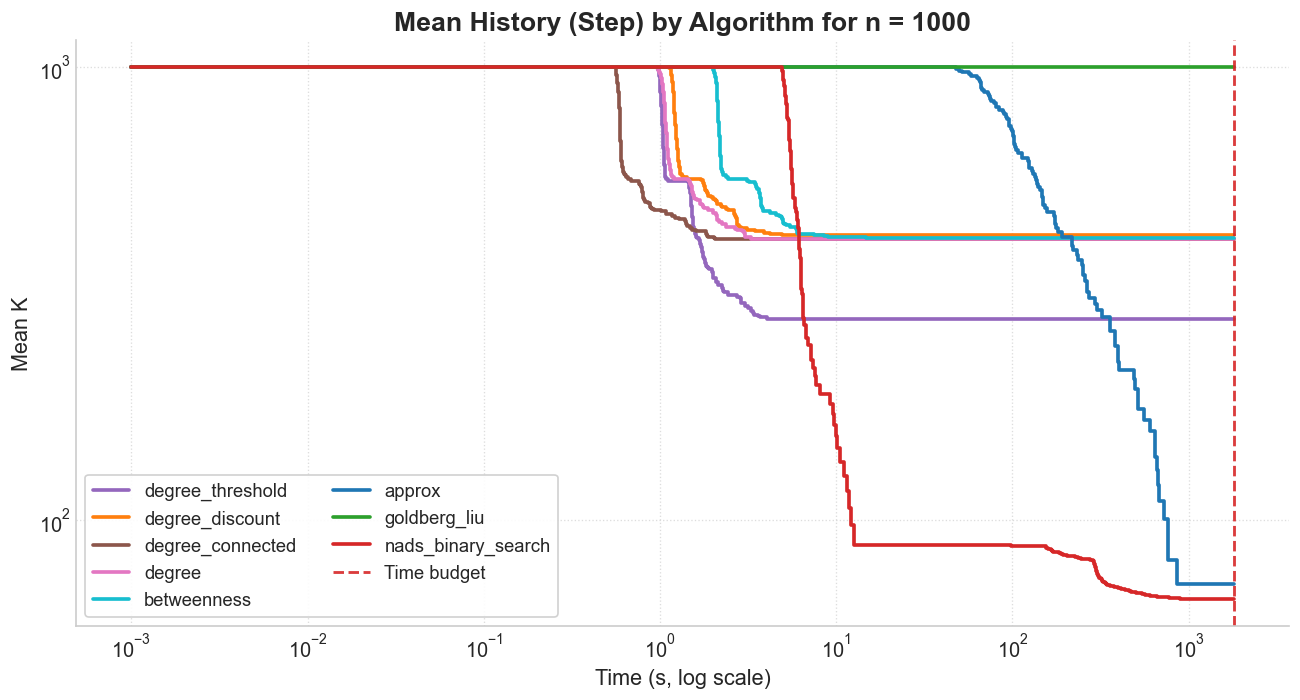

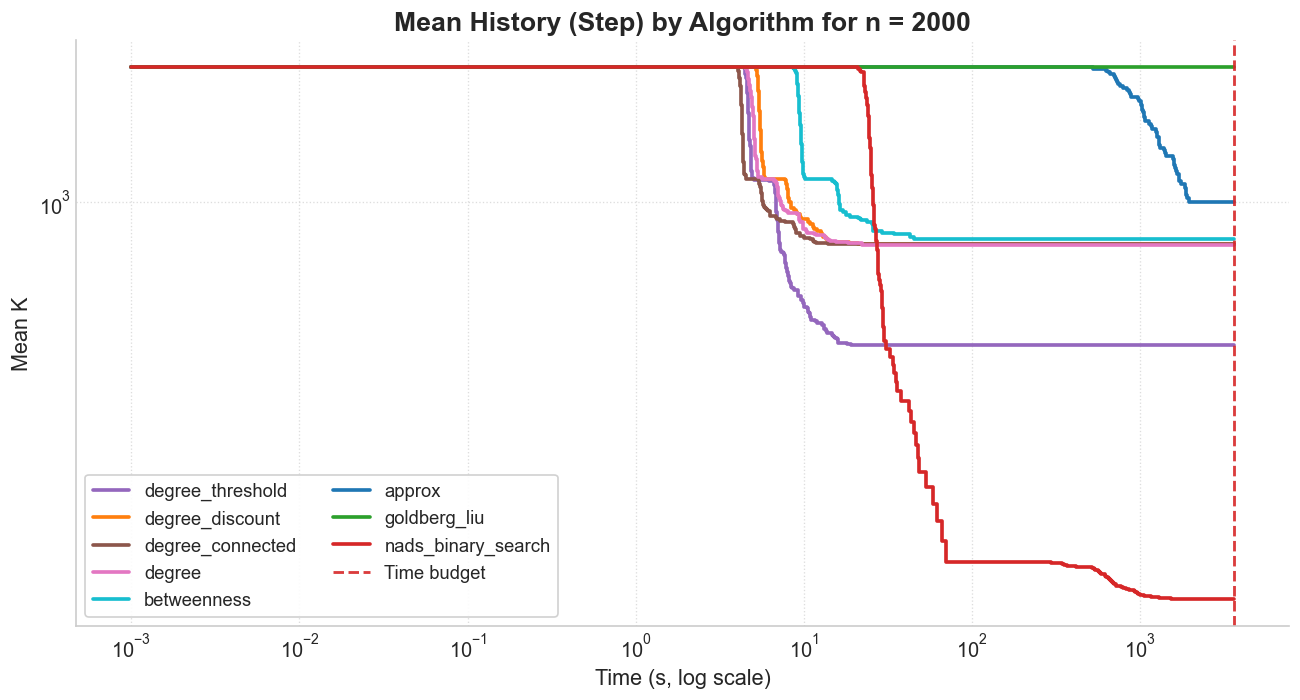

In [48]:
show_std_band = 0

def parse_history(raw):
    if raw is None or (isinstance(raw, float) and pd.isna(raw)):
        return None
    if isinstance(raw, str):
        raw = raw.strip()
        if not raw:
            return None
        try:
            raw = json.loads(raw)
        except json.JSONDecodeError:
            raw = ast.literal_eval(raw)

    if not isinstance(raw, (list, tuple)) or len(raw) == 0:
        return None

    arr = np.asarray(raw, dtype=float)
    if arr.ndim != 2 or arr.shape[1] < 2:
        return None

    values = arr[:, 0]
    times = arr[:, 1]

    finite_mask = np.isfinite(values) & np.isfinite(times)
    if not np.any(finite_mask):
        return None

    values = values[finite_mask]
    times = times[finite_mask]

    order = np.argsort(times)
    return times[order], values[order]

def mean_step_curve(histories, t_end=None):
    parsed = [parse_history(h) for h in histories]
    parsed = [p for p in parsed if p is not None]
    if not parsed:
        return None

    all_event_times = np.concatenate([p[0] for p in parsed])
    all_event_times = all_event_times[np.isfinite(all_event_times)]
    if all_event_times.size == 0:
        return None

    if t_end is not None and float(t_end) > 0:
        t_grid = np.unique(np.concatenate(([0.0], all_event_times, [float(t_end)])))
    else:
        t_grid = np.unique(np.concatenate(([0.0], all_event_times)))

    mean_values = []
    for t_hist, k_hist in parsed:
        idx = np.searchsorted(t_hist, t_grid, side="right") - 1
        idx = np.clip(idx, 0, len(k_hist) - 1)
        mean_values.append(k_hist[idx])

    stacked = np.vstack(mean_values)
    return t_grid, stacked.mean(axis=0)

# Compatibility helper for downstream merged plotting cell.
def mean_std_curve(histories, t_end, n_points=300):
    curve = mean_step_curve(histories, t_end=t_end)
    if curve is None:
        return None
    t_grid, y_mean = curve
    y_std = np.zeros_like(y_mean)
    return t_grid, y_mean, y_std

def best_k_time_from_history(raw_history):
    parsed = parse_history(raw_history)
    if parsed is None:
        return None

    t_hist, k_hist = parsed
    if t_hist.size == 0 or k_hist.size == 0:
        return None

    best_idx = int(np.argmin(k_hist))
    best_k = float(k_hist[best_idx])

    same_best_mask = np.isclose(k_hist, best_k, rtol=0.0, atol=1e-12)
    best_times = t_hist[same_best_mask]
    if best_times.size == 0:
        return None

    best_time = float(np.min(best_times))
    return best_k, best_time

n_values = sorted(df_results["n_nodes"].dropna().unique())
if not n_values:
    raise ValueError("No n_nodes values found in df_results.")

history_algorithms = [a for a in available_algorithms if a != "high_thetas"]

for n in n_values:
    df_n = df_results[df_results["n_nodes"] == n].copy()
    budget_s = (n / 100) * 180
    fig, ax = plt.subplots(figsize=(11, 6), dpi=120)

    plotted = 0
    for alg in history_algorithms:
        histories = df_n.loc[df_n["algorithm"] == alg, "history"].tolist()
        curve = mean_step_curve(histories, t_end=budget_s)
        if curve is None:
            continue
        t_alg, y_mean = curve
        t_plot = np.maximum(t_alg, 1e-3)
        ax.step(
            t_plot,
            y_mean,
            where="post",
            linewidth=2.2,
            color=ALGO_COLORS.get(alg, "#4c4c4c"),
            label=alg,
        )
        plotted += 1

    if plotted == 0:
        plt.close(fig)
        continue

    ax.axvline(
        budget_s,
        color="#d62728",
        linestyle="--",
        linewidth=1.7,
        alpha=0.9,
        label="Time budget",
    )
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.set_title(f"Mean History (Step) by Algorithm for n = {int(n)}", weight="bold")
    ax.set_xlabel("Time (s, log scale)")
    ax.set_ylabel("Mean K")
    ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.65)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(loc="lower left", frameon=True, framealpha=0.9, ncols=2)

    fig.tight_layout()
    if save:
        fig.savefig(figures_dir / f"mean_history_n_{int(n)}.png", dpi=220, bbox_inches="tight")
    plt.show()

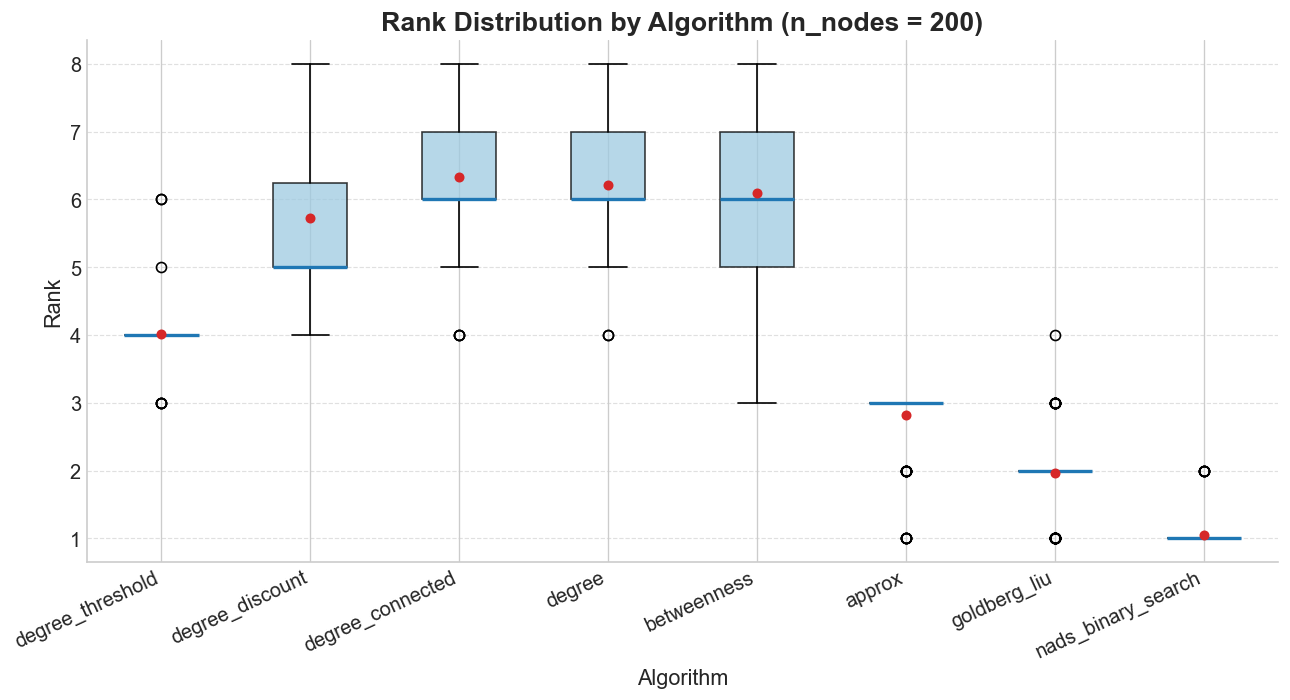

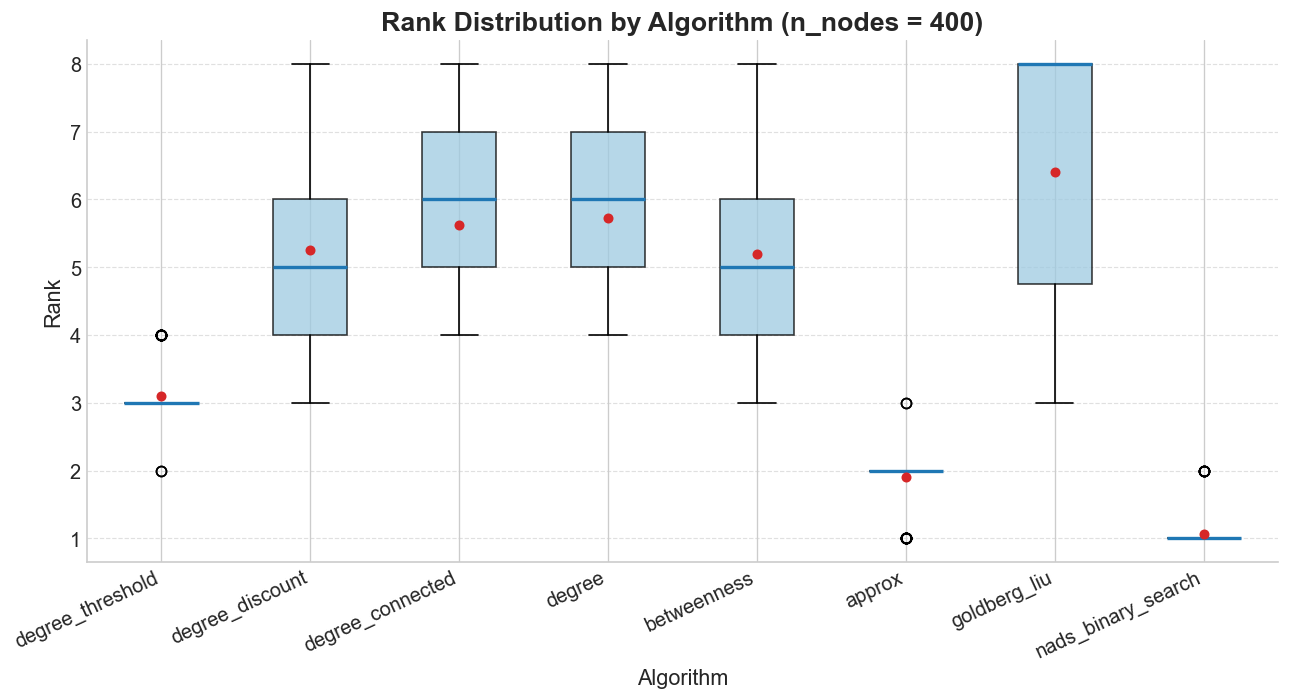

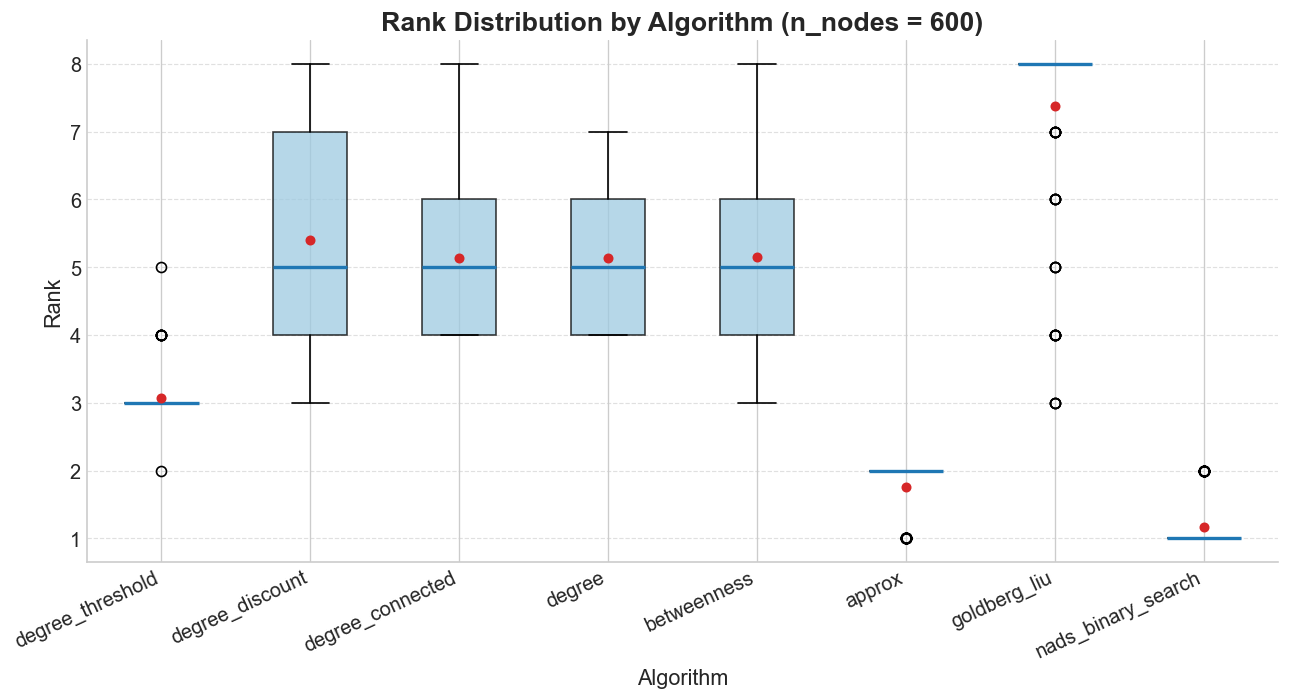

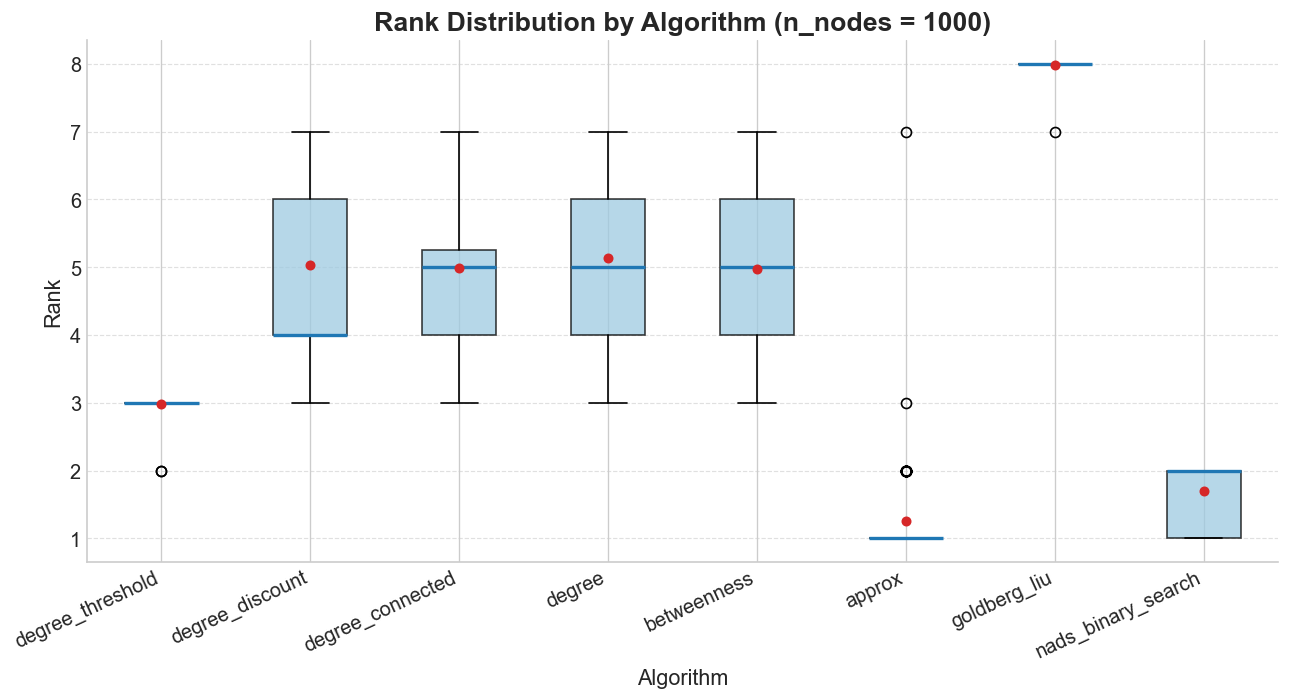

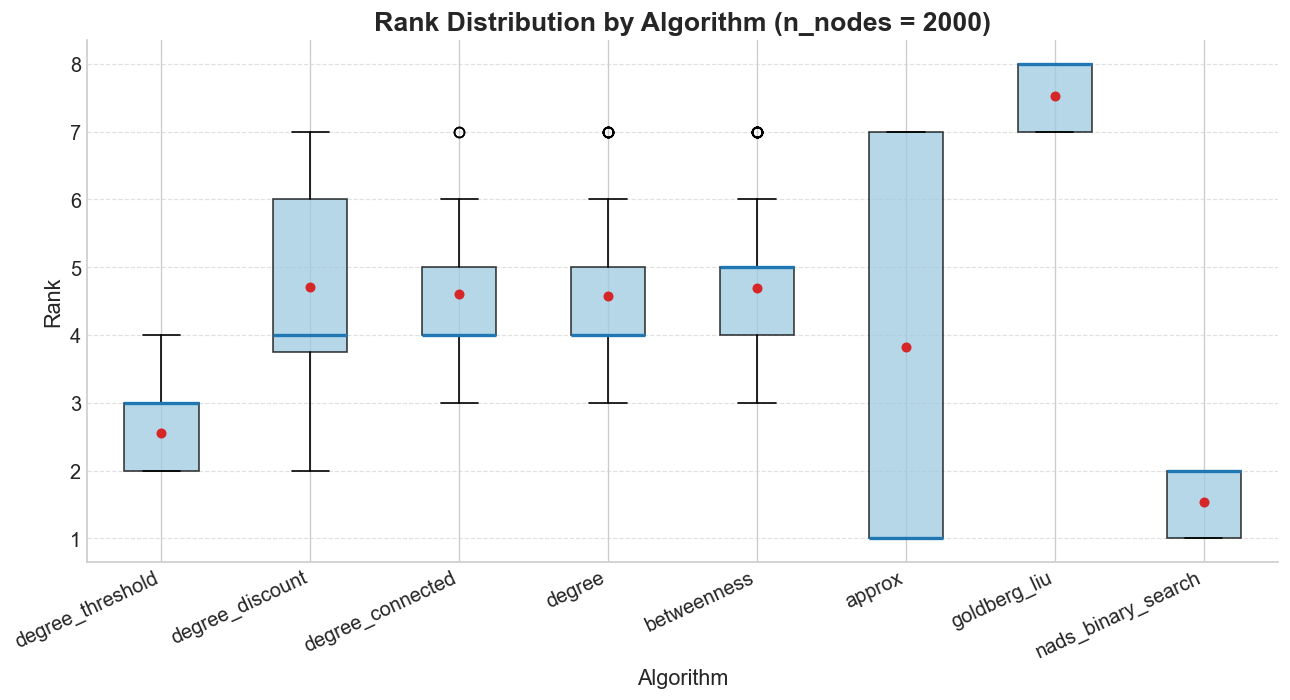

In [53]:
candidate_dims = ["n_nodes", "c", "seed"]
instance_keys = [col for col in candidate_dims if col in df_results.columns]

if "algorithm" not in df_results.columns or "K" not in df_results.columns:
    raise ValueError("df_results must contain at least 'algorithm' and 'K' columns.")
if "n_nodes" not in df_results.columns:
    raise ValueError("df_results must contain 'n_nodes' for this plot.")
if not instance_keys:
    raise ValueError("At least one of ['n_nodes', 'c', 'seed'] must be present in df_results.")

required_cols = instance_keys + ["algorithm"]
rank_source_first = df_results.dropna(subset=required_cols).copy()
rank_source_first = rank_source_first[rank_source_first["algorithm"] != "high_thetas"].copy()

rank_algorithms = [
    a for a in algorithm_order
    if a in rank_source_first["algorithm"].unique() and a != "high_thetas"
 ]
if not rank_algorithms:
    rank_algorithms = sorted(rank_source_first["algorithm"].dropna().unique())

instances = rank_source_first[instance_keys].drop_duplicates().copy()
instances["_k"] = 1
algorithms_df = pd.DataFrame({"algorithm": rank_algorithms, "_k": 1})

rank_complete = instances.merge(algorithms_df, on="_k", how="inner").drop(columns=["_k"])
k_values = rank_source_first[instance_keys + ["algorithm", "K"]].copy()
rank_complete = rank_complete.merge(k_values, on=instance_keys + ["algorithm"], how="left")

rank_complete["K_for_rank"] = rank_complete["K"].fillna(np.inf)
rank_complete["rank_in_instance"] = (
    rank_complete.groupby(instance_keys)["K_for_rank"]
    .rank(method="min", ascending=True)
    .astype(int)
)

for n in sorted(rank_complete["n_nodes"].dropna().unique()):
    df_n = rank_complete[rank_complete["n_nodes"] == n].copy()
    if df_n.empty:
        continue

    box_data = [
        df_n.loc[df_n["algorithm"] == alg, "rank_in_instance"].dropna().to_numpy()
        for alg in rank_algorithms
    ]

    if all(len(arr) == 0 for arr in box_data):
        continue

    fig, ax = plt.subplots(figsize=(11, 6), dpi=120)
    bp = ax.boxplot(
        box_data,
        tick_labels=rank_algorithms,
        patch_artist=True,
        showmeans=True,
        meanprops={"marker": "o", "markerfacecolor": "#d62728", "markeredgecolor": "#d62728", "markersize": 5},
    )

    for patch in bp["boxes"]:
        patch.set_facecolor("#9ecae1")
        patch.set_alpha(0.75)
    for median in bp["medians"]:
        median.set_color("#1f77b4")
        median.set_linewidth(2.0)

    ax.set_title(f"Rank Distribution by Algorithm (n_nodes = {int(n)})", weight="bold")
    ax.set_xlabel("Algorithm")
    ax.set_ylabel("Rank")
    ax.grid(True, axis="y", linestyle="--", linewidth=0.7, alpha=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.xticks(rotation=25, ha="right")

    fig.tight_layout()
    if save:
        fig.savefig(figures_dir / f"rank_boxplot_n_{int(n)}.png", dpi=220, bbox_inches="tight")
    plt.show()